In [41]:
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
import json
import os
from qiskit.quantum_info import SparsePauliOp
from collections import Counter
from fcc import ProteinShapeDecoder, ProteinShapeFileGen
from fcc.fcc_protein_shape import turns_to_bitstring
from fcc.measurement_utils import _evaluate_sparsepauli
from fcc.fcc_peptide import Peptide

In [42]:
# Extract classical results
cs_dir = "../classical_search/cs_res/"

def relabel_turns(turns: str) -> str:
    """Relabels the turns from the classical search to the ones used in the quantum search."""
    mapping = {
        "0": "0",
        "1": "2", 
        "2": "4",
        "3": "6",
        "4": "8",
        "5": "a",
        "6": "1",
        "7": "3",
        "8": "5",
        "9": "7",
        "a": "9",
        "b": "b"
    }
    return "".join([mapping[turn] for turn in turns])


def load_top_cls_solns(file_name: str) -> list:
    top_cls_turns = []
    with open(cs_dir + file_name, "r") as file:
        data = file.read()
        # Split by line
        data_by_line = data.split("\n")
        for line in data_by_line:
            if len(line.split("\t")) == 2:
                [energy, turns] = line.split("\t")
                top_cls_turns.append([relabel_turns(turns), float(energy)])
    return top_cls_turns

def convert_bitstring_to_turns(soln_bitstring: str, main_seq: str) -> str:
    """Converts a solution bitstring (given by the quantum algorithm) to the
    turns."""
    encoding = {
        "0000": "0",
        "0011": "1",
        "1100": "2",
        "1111": "3",
        "1001": "4",
        "0101": "5",
        "1010": "6",
        "0110": "7",
        "1000": "8",
        "0100": "9",
        "1011": "a",
        "0111": "b",
        "0001": "x", # unphysical
        "0010": "x", # unphysical
        "1101": "x", # unphysical
        "1110": "x", # unphysical
    }
    peptide_len = len(main_seq)
    config_bitstring = soln_bitstring[-(4 * peptide_len - 10) :]
    # Add the first 4 bits corresponding to the fixed first turn (0000)
    full_config_bitstring = config_bitstring + "0000"
    # Add the two qubits at positions 6 & 7 from the right (00)
    full_config_bitstring = (
        full_config_bitstring[:-6] + "00" + full_config_bitstring[-6:]
    )
    # Reverse the bitstring
    full_config_bitstring = full_config_bitstring[::-1]
    length_turns = len(full_config_bitstring) // 4
    turns = ""
    for i in range(length_turns):
        turn = full_config_bitstring[i * 4 : (i + 1) * 4]
        turns += encoding[turn]
    # Reverse the turns
    return turns[::-1]


# Function to load the qubit_op from the existing directory

def load_qubit_op(main_seq, r2_threshold, ham_dir="fcc_hamilts"):
    """
    Load the Hamiltonian operator from a JSON file.
    
    Args:
        main_seq (str): The amino acid sequence (e.g., "KLVFFA")
        r2_threshold (float): Threshold for R2 filtering
        ham_dir (str): Directory where the Hamiltonian is stored
    
    Returns:
        SparsePauliOp: The qubit Hamiltonian operator
    """
    file_name = f"{main_seq}_{len(main_seq)}AAs_R2_{int(r2_threshold * 1000)}.json"
    os.makedirs(ham_dir, exist_ok=True)
    file_path = os.path.join(ham_dir, file_name)
    
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Hamiltonian not found at: {file_path}")
    
    print(f"✅ Loaded Hamiltonian from: {file_path}")
    
    with open(file_path, "r") as f:
        data = json.load(f)
        num_qubits = data["num_qubits"]
        sparse_op_list = [(label, coeff) for label, coeff in data["sparse_list"]]
    
    qubit_op = SparsePauliOp.from_list(sparse_op_list, num_qubits=num_qubits)
    return qubit_op

Load the problem Hamiltonian

In [43]:
main_seq="KLVFFA"
qubit_op = load_qubit_op(main_seq, r2_threshold=1.0)
print(qubit_op.size)

✅ Loaded Hamiltonian from: fcc_hamilts/KLVFFA_6AAs_R2_1000.json
18133


In [44]:
# Get top 100 solutions from classical search results
top_cls_solns = load_top_cls_solns(f"{len(main_seq)}AA_{main_seq}_topobj.txt")[:100]
top_cls_solns[:10]

[['97490', -30.57],
 ['a9720', -30.55],
 ['8b520', -30.55],
 ['70b90', -30.45],
 ['81490', -30.45],
 ['31a20', -30.43],
 ['31820', -30.43],
 ['2b580', -30.43],
 ['9a180', -30.43],
 ['5b580', -30.33]]

# Load VQEC sampler results mps sim, R2=1

There are a total of 94 bitstrings.
✅ Loaded 94 valid bitstrings.
❌ Dropped 0 unphysical turn sequences (with 'x').


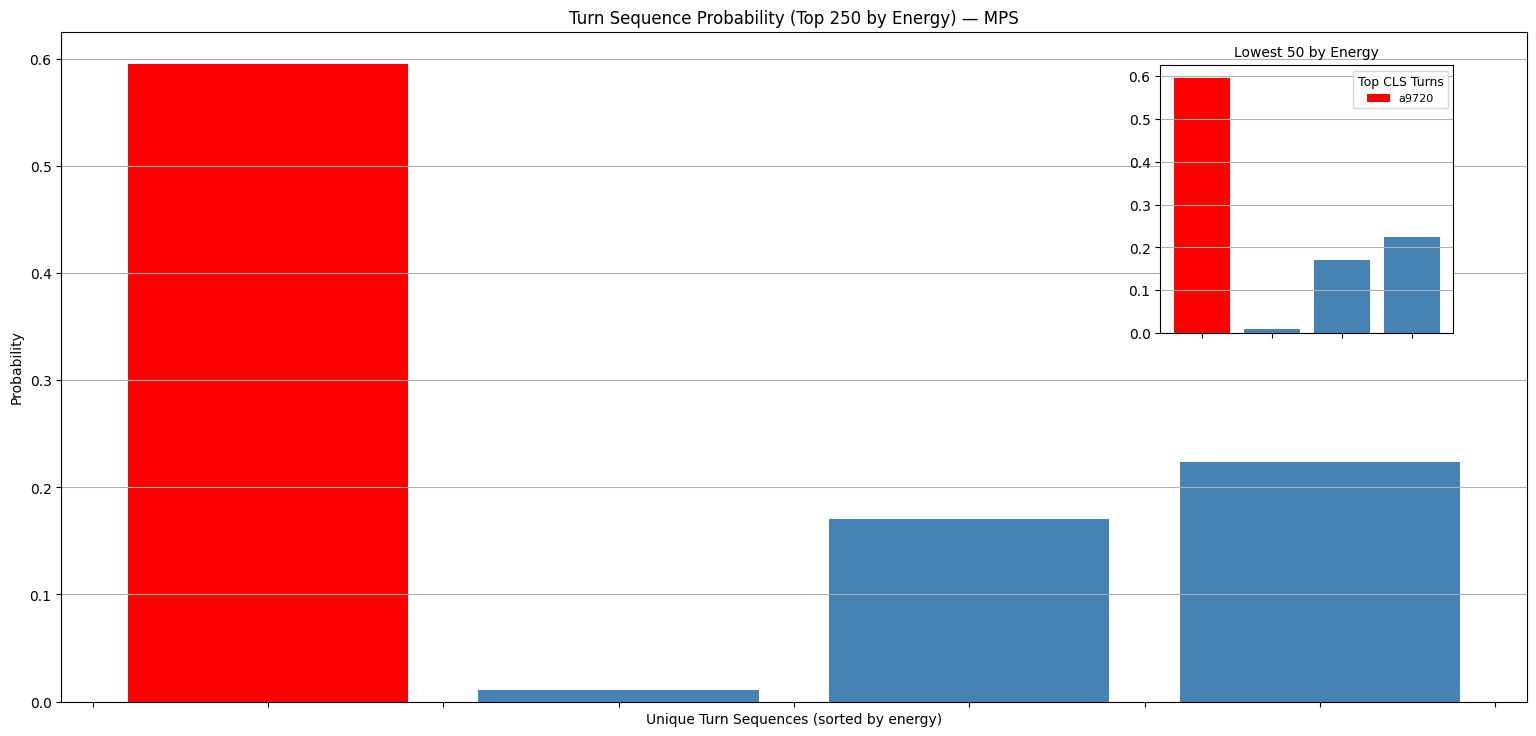

In [37]:
# Paths
base_dir = "../res/vqec_hw/KLVFFA_2025-06-04-14-55-11_aer_simulator_matrix_product_state_sampled"
metadata_path = os.path.join(base_dir, "metadata.json")
sampling_results_path = os.path.join(base_dir, "sampling_results.json")

# Load metadata and sampling results
with open(metadata_path, "r") as f:
    metadata = json.load(f)

with open(sampling_results_path, "r") as f:
    sampling_data = json.load(f)

print("There are a total of", len(sampling_data), "bitstrings.")
main_seq = metadata["main_seq"]

# Process bitstrings
turn_seq_triplets = []
dropped_count = 0
for bitstring, count in sampling_data.items():
    turn_seq = convert_bitstring_to_turns(bitstring, main_seq)
    if "x" in turn_seq:
        dropped_count += 1
        continue
    turn_seq_triplets.append([turn_seq, bitstring, count])

print(f"✅ Loaded {len(turn_seq_triplets)} valid bitstrings.")
print(f"❌ Dropped {dropped_count} unphysical turn sequences (with 'x').")

# Top classical solutions
top_cls_turns = {'97490', 'a9720', '8b520', '70b90', '81490', '31a20', '31820', '2b580', '9a180', '5b580'}

# Prepare data
turn_strs = [''.join(seq) for seq, _, _ in turn_seq_triplets]
bitstrings = [bitstring for _, bitstring, _ in turn_seq_triplets]
peptide = Peptide(main_seq)
correct_bitstrings = [ProteinShapeDecoder(peptide, b).correct_bitstring for b in bitstrings]
energies = [_evaluate_sparsepauli(bs, qubit_op) for bs in correct_bitstrings]

# Lowest energy per unique turn string
turn_energy_dict = {}
for turn, energy in zip(turn_strs, energies):
    turn_energy_dict[turn] = min(turn_energy_dict.get(turn, energy), energy)

# Count and convert to probabilities
turn_counts = Counter(turn_strs)
total_samples = sum(turn_counts.values())
turn_probs = {k: v / total_samples for k, v in turn_counts.items()}

# Sort
sorted_turns = sorted(turn_probs.keys(), key=lambda t: turn_energy_dict[t])
main_plot_limit = 250
inset_size = 50
sorted_turns = sorted_turns[:main_plot_limit]
x_vals = list(range(len(sorted_turns)))
y_vals = [turn_probs[t] for t in sorted_turns]

# Colors
bar_colors = ['red' if t in top_cls_turns else 'steelblue' for t in sorted_turns]

# Main Plot
fig, ax = plt.subplots(figsize=(16, 8))
bars = ax.bar(x_vals, y_vals, color=bar_colors)
ax.set_ylabel("Probability")
ax.set_xlabel("Unique Turn Sequences (sorted by energy)")
ax.set_title(f"Turn Sequence Probability (Top {main_plot_limit} by Energy) — MPS")
ax.grid(True, axis='y')
ax.tick_params(labelbottom=False)

# Inset
inset_ax = ax.inset_axes([0.75, 0.55, 0.2, 0.4])
x_inset = list(range(min(inset_size, len(sorted_turns))))
y_inset = y_vals[:inset_size]
colors_inset = bar_colors[:inset_size]
bars_inset = inset_ax.bar(x_inset, y_inset, color=colors_inset)
inset_ax.set_title(f"Lowest {inset_size} by Energy", fontsize=10)
inset_ax.tick_params(labelbottom=False)
inset_ax.grid(True, axis='y')

# Legend
legend_handles = []
legend_labels = []
for bar, turn_seq in zip(bars_inset, sorted_turns[:inset_size]):
    if turn_seq in top_cls_turns:
        legend_handles.append(bar)
        legend_labels.append(turn_seq)

if legend_handles:
    inset_ax.legend(legend_handles, legend_labels, title="Top CLS Turns", fontsize=8, title_fontsize=9, loc="upper right")

plt.tight_layout(pad=3.0)
plt.show()


# Load VQEC sampler results ibm_cleveland, R2=1

There are a total of 63774 bitstrings.
✅ Loaded 32211 valid bitstrings.
❌ Dropped 31563 unphysical turn sequences (with 'x').
✅ Saved energy+count dictionary to cleveland_vqec_sampled_energy_dict.json


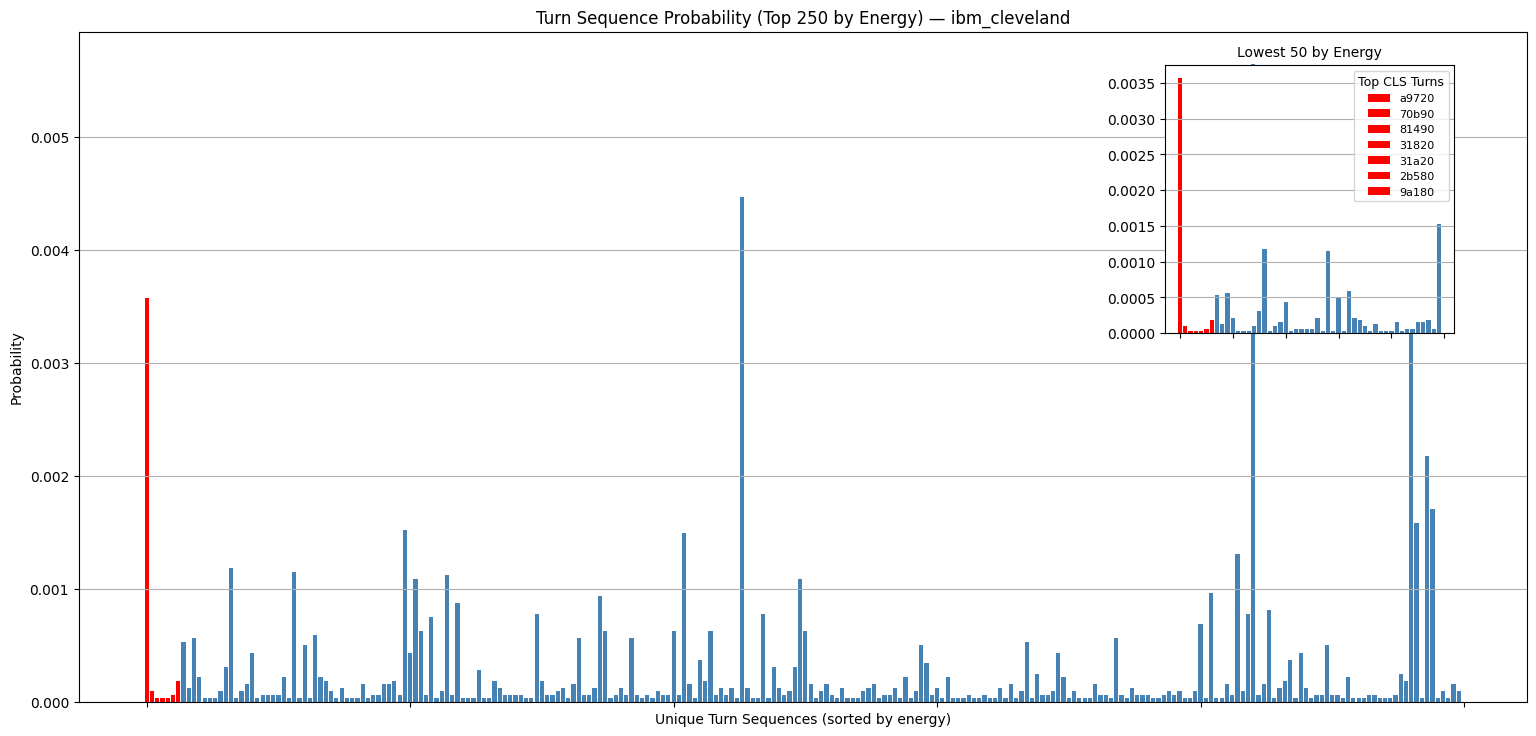

In [38]:
# ---- Load Data ----
base_dir = "../res/vqec_hw/KLVFFA_2025-06-03-02-15-45_ibm_cleveland_sampled"
metadata_path = os.path.join(base_dir, "metadata.json")
sampling_results_path = os.path.join(base_dir, "sampling_results.json")

with open(metadata_path, "r") as f:
    metadata = json.load(f)

with open(sampling_results_path, "r") as f:
    sampling_data = json.load(f)

print("There are a total of", len(sampling_data), "bitstrings.")
main_seq = metadata["main_seq"]

# ---- Parse Turn Sequences ----
turn_seq_triplets = []
dropped_count = 0

for bitstring, count in sampling_data.items():
    turn_seq = convert_bitstring_to_turns(bitstring, main_seq)
    if "x" in turn_seq:
        dropped_count += 1
        continue
    turn_seq_triplets.append([turn_seq, bitstring, count])

print(f"✅ Loaded {len(turn_seq_triplets)} valid bitstrings.")
print(f"❌ Dropped {dropped_count} unphysical turn sequences (with 'x').")

# ---- Classical Reference ----
top_cls_turns = {'97490', 'a9720', '8b520', '70b90', '81490', '31a20', '31820', '2b580', '9a180', '5b580'}

# ---- Energy + Probabilities ----
turn_strs = [''.join(seq) for seq, _, _ in turn_seq_triplets]
bitstrings = [bitstring for _, bitstring, _ in turn_seq_triplets]
peptide = Peptide(main_seq)
correct_bitstrings = [ProteinShapeDecoder(peptide, b).correct_bitstring for b in bitstrings]
energies = [_evaluate_sparsepauli(bs, qubit_op) for bs in correct_bitstrings]

# Lowest energy per unique turn string
turn_energy_dict = {}
for turn, energy in zip(turn_strs, energies):
    turn_energy_dict[turn] = min(turn_energy_dict.get(turn, energy), energy)

# Count and convert to probabilities
turn_counts = Counter(turn_strs)
total_samples = sum(turn_counts.values())
turn_probs = {k: v / total_samples for k, v in turn_counts.items()}

# ---- Save Energy + Prob ----
output_path = "cleveland_vqec_sampled_energy_dict.json"
with open(output_path, "w") as f:
    json.dump({k: {"energy": float(turn_energy_dict[k]), "count": turn_counts[k]} for k in turn_energy_dict}, f, indent=2)
print(f"✅ Saved energy+count dictionary to {output_path}")

# ---- Plotting ----
main_plot_limit = 250
inset_size = 50

sorted_turns = sorted(turn_probs.keys(), key=lambda t: turn_energy_dict[t])
sorted_turns = sorted_turns[:main_plot_limit]
x_vals = list(range(len(sorted_turns)))
y_vals = [turn_probs[t] for t in sorted_turns]
bar_colors = ['red' if t in top_cls_turns else 'steelblue' for t in sorted_turns]

# --- Main Plot ---
fig, ax = plt.subplots(figsize=(16, 8))
bars = ax.bar(x_vals, y_vals, color=bar_colors)
ax.set_ylabel("Probability")
ax.set_xlabel("Unique Turn Sequences (sorted by energy)")
ax.set_title(f"Turn Sequence Probability (Top {main_plot_limit} by Energy) — ibm_cleveland")
ax.grid(True, axis='y')
ax.tick_params(labelbottom=False)

# --- Inset Plot ---
inset_ax = ax.inset_axes([0.75, 0.55, 0.2, 0.4])
x_inset = list(range(min(inset_size, len(sorted_turns))))
y_inset = y_vals[:inset_size]
colors_inset = bar_colors[:inset_size]
bars_inset = inset_ax.bar(x_inset, y_inset, color=colors_inset)
inset_ax.set_title(f"Lowest {inset_size} by Energy", fontsize=10)
inset_ax.tick_params(labelbottom=False)
inset_ax.grid(True, axis='y')

# --- Add Legend for Red Bars ---
legend_handles = []
legend_labels = []

for bar, turn_seq in zip(bars_inset, sorted_turns[:inset_size]):
    if turn_seq in top_cls_turns:
        legend_handles.append(bar)
        legend_labels.append(turn_seq)

if legend_handles:
    inset_ax.legend(legend_handles, legend_labels, title="Top CLS Turns", fontsize=8, title_fontsize=9, loc="upper right")

plt.tight_layout(pad=3.0)
plt.show()


# VQEC sampling results from ibm_kingston, R2=1

There are a total of 10403 bitstrings.
✅ Loaded 7628 valid bitstrings.
❌ Dropped 2775 unphysical turn sequences (with 'x').
✅ Saved energy+count dictionary to ibm_kingston_vqec_sampled_energy_dict.json


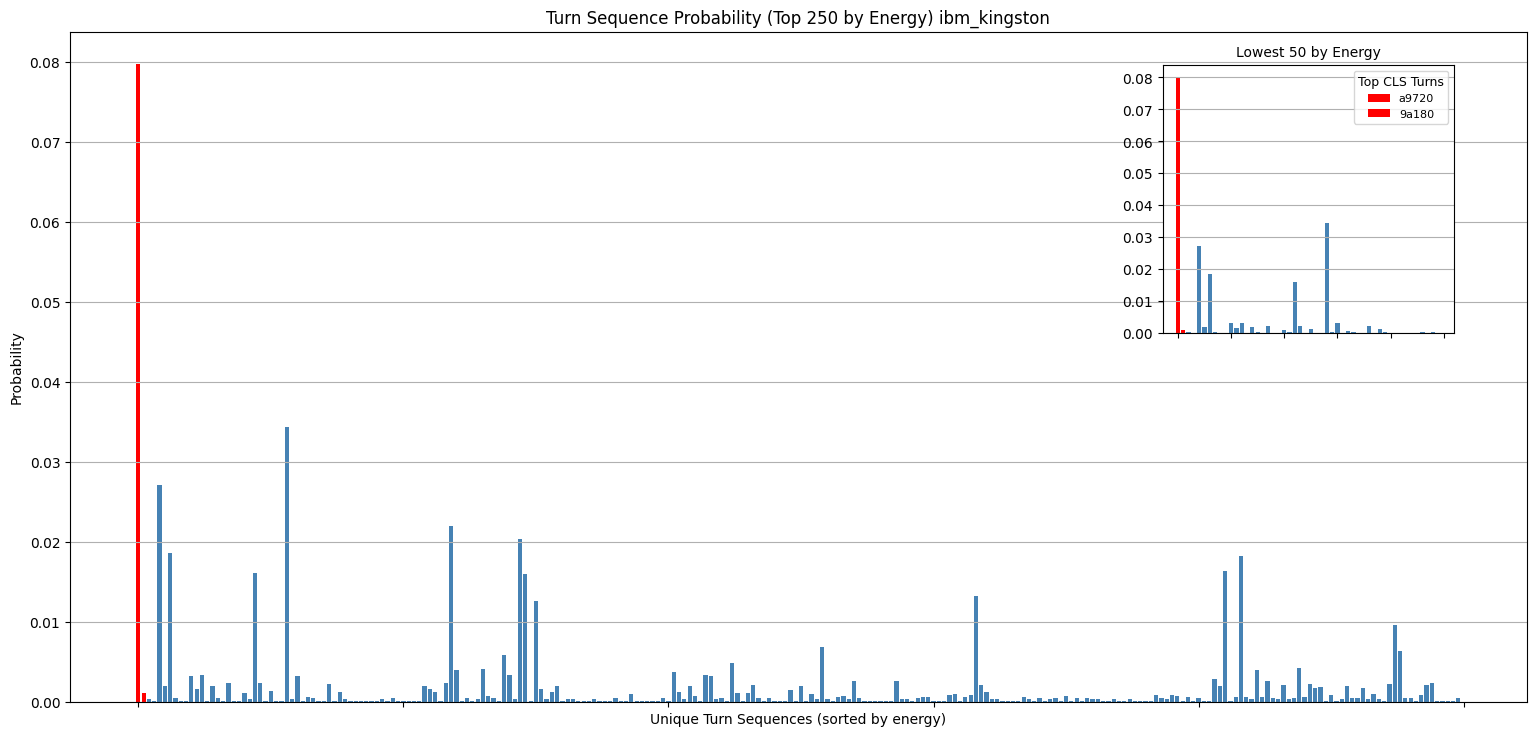

In [39]:
# Path to the folder with saved sampling results using opt parameters from data/protein-folding-qc/res/vqec_hw/KLVFFA_2025-06-03-02-20-45_ibm_kingston_sampled
base_dir = "../res/vqec_hw/KLVFFA_2025-06-03-02-20-45_ibm_kingston_sampled"

# Full paths to the JSON files
metadata_path = os.path.join(base_dir, "metadata.json")
sampling_results_path = os.path.join(base_dir, "sampling_results.json")

# Load metadata
with open(metadata_path, "r") as f:
    metadata = json.load(f)

# Load sampling results
with open(sampling_results_path, "r") as f:
    sampling_data = json.load(f)

print("There are a total of", len(sampling_data), "bitstrings.")
main_seq = metadata["main_seq"]

turn_seq_triplets = []
dropped_count = 0

for bitstring, count in sampling_data.items():
    turn_seq = convert_bitstring_to_turns(bitstring, main_seq)
    if "x" in turn_seq:
        dropped_count += 1
        continue
    turn_seq_triplets.append([turn_seq, bitstring, count])

print(f"✅ Loaded {len(turn_seq_triplets)} valid bitstrings.")
print(f"❌ Dropped {dropped_count} unphysical turn sequences (with 'x').")

top_cls_turns = {'97490', 'a9720', '8b520', '70b90', '81490', '31a20', '31820', '2b580', '9a180', '5b580'}

turn_strs = [''.join(seq) for seq, _, _ in turn_seq_triplets]
bitstrings = [bitstring for _, bitstring, _ in turn_seq_triplets]
peptide = Peptide(main_seq)
correct_bitstrings = [ProteinShapeDecoder(peptide, b).correct_bitstring for b in bitstrings]
energies = [_evaluate_sparsepauli(bs, qubit_op) for bs in correct_bitstrings]

turn_energy_dict = {}
for turn, energy in zip(turn_strs, energies):
    turn_energy_dict[turn] = min(turn_energy_dict.get(turn, energy), energy)

turn_counts = Counter(turn_strs)
total_samples = sum(turn_counts.values())
turn_probs = {k: v / total_samples for k, v in turn_counts.items()}

output_path = "ibm_kingston_vqec_sampled_energy_dict.json"
with open(output_path, "w") as f:
    json.dump({k: {"energy": float(turn_energy_dict[k]), "count": turn_counts[k]} for k in turn_energy_dict}, f, indent=2)
print(f"✅ Saved energy+count dictionary to {output_path}")

with open(output_path, "r") as f:
    sampled_data = json.load(f)

turn_energy_dict = {k: v["energy"] for k, v in sampled_data.items()}
turn_counts = {k: v["count"] for k, v in sampled_data.items()}
total_samples = sum(turn_counts.values())
turn_probs = {k: v / total_samples for k, v in turn_counts.items()}

main_plot_limit = 250
inset_size = 50

sorted_turns = sorted(turn_probs.keys(), key=lambda t: turn_energy_dict[t])
sorted_turns = sorted_turns[:main_plot_limit]
x_vals = list(range(len(sorted_turns)))
y_vals = [turn_probs[t] for t in sorted_turns]
bar_colors = ['red' if t in top_cls_turns else 'steelblue' for t in sorted_turns]

fig, ax = plt.subplots(figsize=(16, 8))
bars = ax.bar(x_vals, y_vals, color=bar_colors)
ax.set_ylabel("Probability")
ax.set_xlabel("Unique Turn Sequences (sorted by energy)")
ax.set_title(f"Turn Sequence Probability (Top {main_plot_limit} by Energy) ibm_kingston")
ax.grid(True, axis='y')
ax.tick_params(labelbottom=False)

inset_ax = ax.inset_axes([0.75, 0.55, 0.2, 0.4])
x_inset = list(range(min(inset_size, len(sorted_turns))))
y_inset = y_vals[:inset_size]
colors_inset = bar_colors[:inset_size]
bars_inset = inset_ax.bar(x_inset, y_inset, color=colors_inset)
inset_ax.set_title(f"Lowest {inset_size} by Energy", fontsize=10)
inset_ax.tick_params(labelbottom=False)
inset_ax.grid(True, axis='y')

legend_handles = []
legend_labels = []

for bar, turn_seq in zip(bars_inset, sorted_turns[:inset_size]):
    if turn_seq in top_cls_turns:
        legend_handles.append(bar)
        legend_labels.append(turn_seq)

if legend_handles:
    inset_ax.legend(legend_handles, legend_labels, title="Top CLS Turns", fontsize=8, title_fontsize=9, loc="upper right")

plt.tight_layout(pad=3.0)
plt.show()


# VQEC sampling results from ibm_cleveland, R2=1, with DD

There are a total of 56089 bitstrings.
✅ Loaded 37797 valid bitstrings.
❌ Dropped 18292 unphysical turn sequences (with 'x').
✅ Saved energy+count dictionary to cleveland_vqec_sampled_dd_energy_dict.json


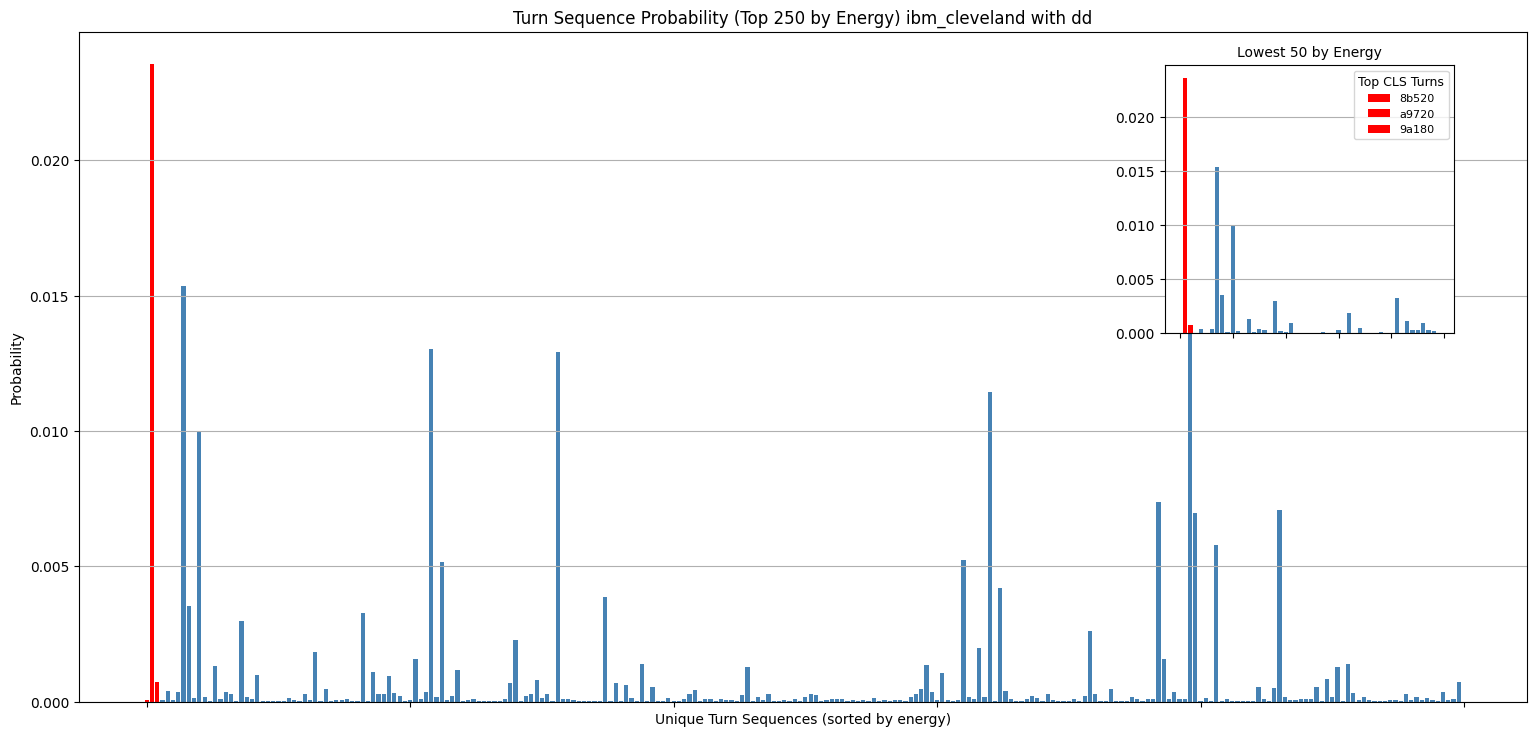

In [40]:
# Path to the folder with saved sampling results using opt parameters from data/protein-folding-qc/res/vqec_hw/KLVFFA_2025-06-03-19-31-38_ibm_cleveland_sampled
base_dir = "../res/vqec_hw/KLVFFA_2025-06-03-19-31-38_ibm_cleveland_sampled"

# Full paths to the JSON files
metadata_path = os.path.join(base_dir, "metadata.json")
sampling_results_path = os.path.join(base_dir, "sampling_results.json")

# Load metadata
with open(metadata_path, "r") as f:
    metadata = json.load(f)

# Load sampling results
with open(sampling_results_path, "r") as f:
    sampling_data = json.load(f)

print("There are a total of", len(sampling_data), "bitstrings.")
main_seq = metadata["main_seq"]

turn_seq_triplets = []
dropped_count = 0

for bitstring, count in sampling_data.items():
    turn_seq = convert_bitstring_to_turns(bitstring, main_seq)
    if "x" in turn_seq:
        dropped_count += 1
        continue
    turn_seq_triplets.append([turn_seq, bitstring, count])

print(f"✅ Loaded {len(turn_seq_triplets)} valid bitstrings.")
print(f"❌ Dropped {dropped_count} unphysical turn sequences (with 'x').")

top_cls_turns = {'97490', 'a9720', '8b520', '70b90', '81490', '31a20', '31820', '2b580', '9a180', '5b580'}

turn_strs = [''.join(seq) for seq, _, _ in turn_seq_triplets]
bitstrings = [bitstring for _, bitstring, _ in turn_seq_triplets]
peptide = Peptide(main_seq)
correct_bitstrings = [ProteinShapeDecoder(peptide, b).correct_bitstring for b in bitstrings]
energies = [_evaluate_sparsepauli(bs, qubit_op) for bs in correct_bitstrings]

turn_energy_dict = {}
for turn, energy in zip(turn_strs, energies):
    turn_energy_dict[turn] = min(turn_energy_dict.get(turn, energy), energy)

turn_counts = Counter(turn_strs)
total_samples = sum(turn_counts.values())
turn_probs = {k: v / total_samples for k, v in turn_counts.items()}

output_path = "cleveland_vqec_sampled_dd_energy_dict.json"
with open(output_path, "w") as f:
    json.dump({k: {"energy": float(turn_energy_dict[k]), "count": turn_counts[k]} for k in turn_energy_dict}, f, indent=2)
print(f"✅ Saved energy+count dictionary to {output_path}")

with open(output_path, "r") as f:
    sampled_data = json.load(f)

turn_energy_dict = {k: v["energy"] for k, v in sampled_data.items()}
turn_counts = {k: v["count"] for k, v in sampled_data.items()}
total_samples = sum(turn_counts.values())
turn_probs = {k: v / total_samples for k, v in turn_counts.items()}

main_plot_limit = 250
inset_size = 50

sorted_turns = sorted(turn_probs.keys(), key=lambda t: turn_energy_dict[t])
sorted_turns = sorted_turns[:main_plot_limit]
x_vals = list(range(len(sorted_turns)))
y_vals = [turn_probs[t] for t in sorted_turns]
bar_colors = ['red' if t in top_cls_turns else 'steelblue' for t in sorted_turns]

fig, ax = plt.subplots(figsize=(16, 8))
bars = ax.bar(x_vals, y_vals, color=bar_colors)
ax.set_ylabel("Probability")
ax.set_xlabel("Unique Turn Sequences (sorted by energy)")
ax.set_title(f"Turn Sequence Probability (Top {main_plot_limit} by Energy) ibm_cleveland with dd")
ax.grid(True, axis='y')
ax.tick_params(labelbottom=False)

inset_ax = ax.inset_axes([0.75, 0.55, 0.2, 0.4])
x_inset = list(range(min(inset_size, len(sorted_turns))))
y_inset = y_vals[:inset_size]
colors_inset = bar_colors[:inset_size]
bars_inset = inset_ax.bar(x_inset, y_inset, color=colors_inset)
inset_ax.set_title(f"Lowest {inset_size} by Energy", fontsize=10)
inset_ax.tick_params(labelbottom=False)
inset_ax.grid(True, axis='y')

legend_handles = []
legend_labels = []

for bar, turn_seq in zip(bars_inset, sorted_turns[:inset_size]):
    if turn_seq in top_cls_turns:
        legend_handles.append(bar)
        legend_labels.append(turn_seq)

if legend_handles:
    inset_ax.legend(legend_handles, legend_labels, title="Top CLS Turns", fontsize=8, title_fontsize=9, loc="upper right")

plt.tight_layout(pad=3.0)
plt.show()


There are a total of 12517 bitstrings.
✅ Loaded 8874 valid bitstrings.
❌ Dropped 3643 unphysical turn sequences (with 'x').
✅ Saved energy+count dictionary to kingston_vqec_sampled_dd_energy_dict.json


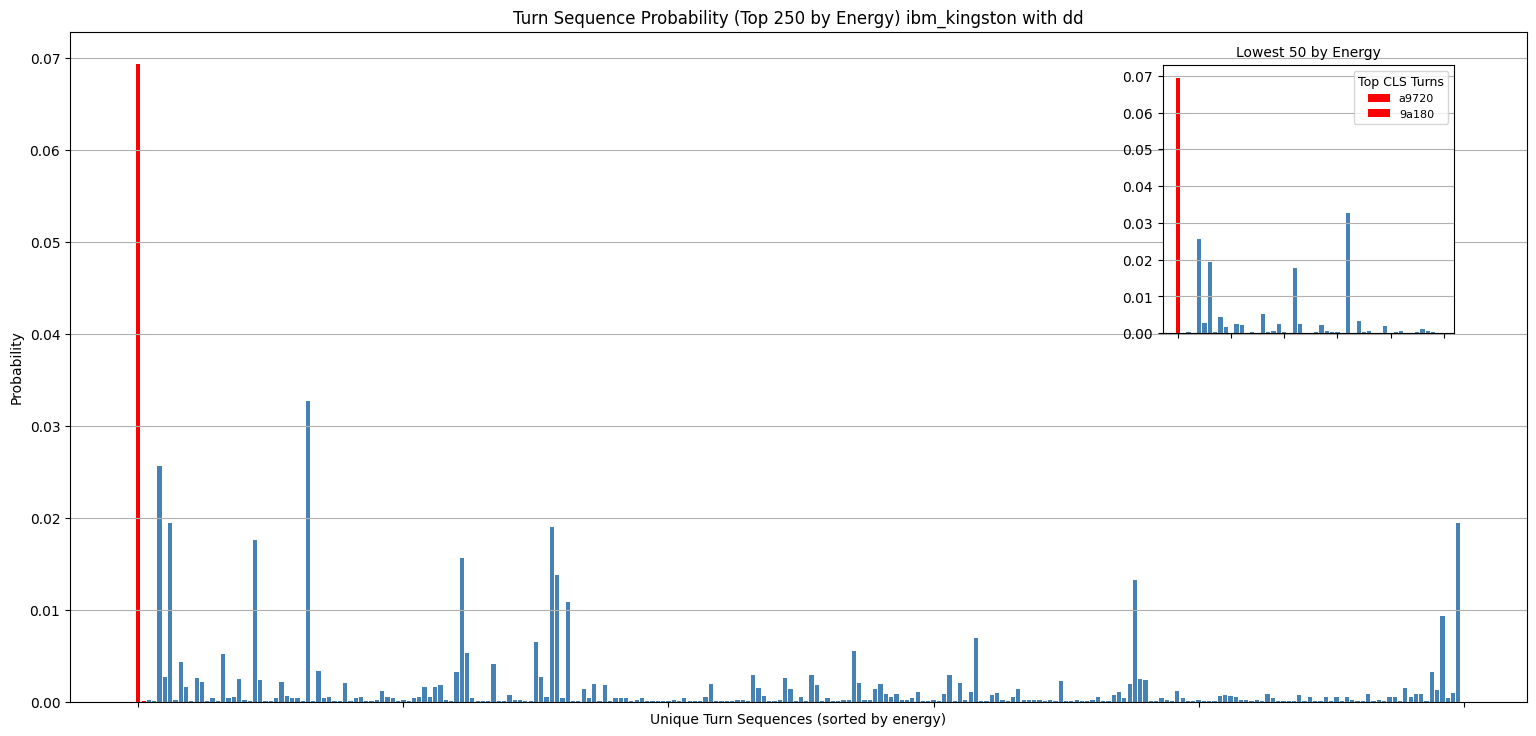

In [47]:
# Path to the folder with saved sampling results using opt parameters from data/protein-folding-qc/res/vqec_hw/KLVFFA_2025-06-05-16-11-15_ibm_kingston_sampled
base_dir = "../res/vqec_hw/KLVFFA_2025-06-05-16-11-15_ibm_kingston_sampled"

# Full paths to the JSON files
metadata_path = os.path.join(base_dir, "metadata.json")
sampling_results_path = os.path.join(base_dir, "sampling_results.json")

# Load metadata
with open(metadata_path, "r") as f:
    metadata = json.load(f)

# Load sampling results
with open(sampling_results_path, "r") as f:
    sampling_data = json.load(f)

print("There are a total of", len(sampling_data), "bitstrings.")
main_seq = metadata["main_seq"]

turn_seq_triplets = []
dropped_count = 0

for bitstring, count in sampling_data.items():
    turn_seq = convert_bitstring_to_turns(bitstring, main_seq)
    if "x" in turn_seq:
        dropped_count += 1
        continue
    turn_seq_triplets.append([turn_seq, bitstring, count])

print(f"✅ Loaded {len(turn_seq_triplets)} valid bitstrings.")
print(f"❌ Dropped {dropped_count} unphysical turn sequences (with 'x').")

top_cls_turns = {'97490', 'a9720', '8b520', '70b90', '81490', '31a20', '31820', '2b580', '9a180', '5b580'}

turn_strs = [''.join(seq) for seq, _, _ in turn_seq_triplets]
bitstrings = [bitstring for _, bitstring, _ in turn_seq_triplets]
peptide = Peptide(main_seq)
correct_bitstrings = [ProteinShapeDecoder(peptide, b).correct_bitstring for b in bitstrings]
energies = [_evaluate_sparsepauli(bs, qubit_op) for bs in correct_bitstrings]

turn_energy_dict = {}
for turn, energy in zip(turn_strs, energies):
    turn_energy_dict[turn] = min(turn_energy_dict.get(turn, energy), energy)

turn_counts = Counter(turn_strs)
total_samples = sum(turn_counts.values())
turn_probs = {k: v / total_samples for k, v in turn_counts.items()}

output_path = "kingston_vqec_sampled_dd_energy_dict.json"
with open(output_path, "w") as f:
    json.dump({k: {"energy": float(turn_energy_dict[k]), "count": turn_counts[k]} for k in turn_energy_dict}, f, indent=2)
print(f"✅ Saved energy+count dictionary to {output_path}")

with open(output_path, "r") as f:
    sampled_data = json.load(f)

turn_energy_dict = {k: v["energy"] for k, v in sampled_data.items()}
turn_counts = {k: v["count"] for k, v in sampled_data.items()}
total_samples = sum(turn_counts.values())
turn_probs = {k: v / total_samples for k, v in turn_counts.items()}

main_plot_limit = 250
inset_size = 50

sorted_turns = sorted(turn_probs.keys(), key=lambda t: turn_energy_dict[t])
sorted_turns = sorted_turns[:main_plot_limit]
x_vals = list(range(len(sorted_turns)))
y_vals = [turn_probs[t] for t in sorted_turns]
bar_colors = ['red' if t in top_cls_turns else 'steelblue' for t in sorted_turns]

fig, ax = plt.subplots(figsize=(16, 8))
bars = ax.bar(x_vals, y_vals, color=bar_colors)
ax.set_ylabel("Probability")
ax.set_xlabel("Unique Turn Sequences (sorted by energy)")
ax.set_title(f"Turn Sequence Probability (Top {main_plot_limit} by Energy) ibm_kingston with dd")
ax.grid(True, axis='y')
ax.tick_params(labelbottom=False)

inset_ax = ax.inset_axes([0.75, 0.55, 0.2, 0.4])
x_inset = list(range(min(inset_size, len(sorted_turns))))
y_inset = y_vals[:inset_size]
colors_inset = bar_colors[:inset_size]
bars_inset = inset_ax.bar(x_inset, y_inset, color=colors_inset)
inset_ax.set_title(f"Lowest {inset_size} by Energy", fontsize=10)
inset_ax.tick_params(labelbottom=False)
inset_ax.grid(True, axis='y')

legend_handles = []
legend_labels = []

for bar, turn_seq in zip(bars_inset, sorted_turns[:inset_size]):
    if turn_seq in top_cls_turns:
        legend_handles.append(bar)
        legend_labels.append(turn_seq)

if legend_handles:
    inset_ax.legend(legend_handles, legend_labels, title="Top CLS Turns", fontsize=8, title_fontsize=9, loc="upper right")

plt.tight_layout(pad=3.0)
plt.show()
